# Stage 5 — Fuzzification with membership visualisation

In [1]:
from pathlib import Path
import os, warnings
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    pass

def locate_root():
    candidates = [
        Path(os.environ.get("MFAR_PROJECT_ROOT","")),
        Path("/content/drive/MyDrive/MFAR_Modular_Colab_Pipeline"),
        Path.cwd(), Path.cwd().parent
    ]
    for p in candidates:
        if str(p) and (p/"stage_output").exists() and (p/"config").exists():
            return p.resolve()
    raise FileNotFoundError("Project root not found.")

ROOT=locate_root()
RAW=ROOT/"data_raw"
CFG=ROOT/"config"
STAGE=ROOT/"stage_output"
for i in range(1,8):
    (STAGE/f"stage_{i:02d}").mkdir(parents=True,exist_ok=True)
print("ROOT =",ROOT)

Mounted at /content/drive
ROOT = /content/drive/MyDrive/MFAR_Modular_Colab_Pipeline


In [2]:
import matplotlib.pyplot as plt
df=pd.read_csv(STAGE/"stage_04"/"04_fuzzy_input.csv")
df["simulation_time"]=pd.to_datetime(df["simulation_time"],errors="coerce")

def left(x,a,b):
    x=np.asarray(x,dtype=float)
    return np.where(x<=a,1.0,np.where(x>=b,0.0,(b-x)/(b-a)))
def right(x,a,b):
    x=np.asarray(x,dtype=float)
    return np.where(x<=a,0.0,np.where(x>=b,1.0,(x-a)/(b-a)))
def tri(x,a,b,c):
    x=np.asarray(x,dtype=float)
    return np.where((x<=a)|(x>=c),0.0,
        np.where(x==b,1.0,np.where(x<b,(x-a)/(b-a),(c-x)/(c-b))))

In [3]:
for prefix,col in [("origin","origin_queue_ratio"),("destination","destination_queue_ratio")]:
    df[f"mu_{prefix}_queue_low"]=left(df[col],0.5,1.0)
    df[f"mu_{prefix}_queue_medium"]=tri(df[col],0.5,1.25,2.0)
    df[f"mu_{prefix}_queue_high"]=tri(df[col],1.5,2.5,3.5)
    df[f"mu_{prefix}_queue_critical"]=right(df[col],2.5,3.0)

df["mu_berth_available"]=df["berth_availability_at_eta"].clip(0,1)
df["mu_berth_unavailable"]=1-df["mu_berth_available"]
df["mu_wait_short"]=left(df["predicted_wait_min"],5,15)
df["mu_wait_medium"]=tri(df["predicted_wait_min"],5,20,35)
df["mu_wait_long"]=right(df["predicted_wait_min"],20,40)
df["mu_confidence_low"]=left(df["forecast_confidence"],0.4,0.7)
df["mu_confidence_medium"]=tri(df["forecast_confidence"],0.4,0.7,0.9)
df["mu_confidence_high"]=right(df["forecast_confidence"],0.7,0.9)

# New: service gap and capacity shortfall prevent ADD_VESSEL from dominating.
df["mu_service_gap_short"]=left(df["minutes_to_next_departure"],20,45)
df["mu_service_gap_medium"]=tri(df["minutes_to_next_departure"],20,50,90)
df["mu_service_gap_long"]=right(df["minutes_to_next_departure"],60,120)

shortfall_ratio=df["capacity_shortfall_next_60min"]/30.0
df["mu_capacity_shortfall_low"]=left(shortfall_ratio,0.25,0.75)
df["mu_capacity_shortfall_medium"]=tri(shortfall_ratio,0.25,1.0,2.0)
df["mu_capacity_shortfall_high"]=right(shortfall_ratio,1.0,2.5)

status=df["operational_status"].astype(str)
df["mu_state_at_berth"]=status.str.startswith("AT_BERTH").astype(float)
df["mu_state_departing"]=status.str.startswith("DEPARTING").astype(float)
df["mu_state_sailing"]=status.str.contains("SAILING").astype(float)
df["mu_state_approaching"]=status.str.contains("APPROACHING").astype(float)

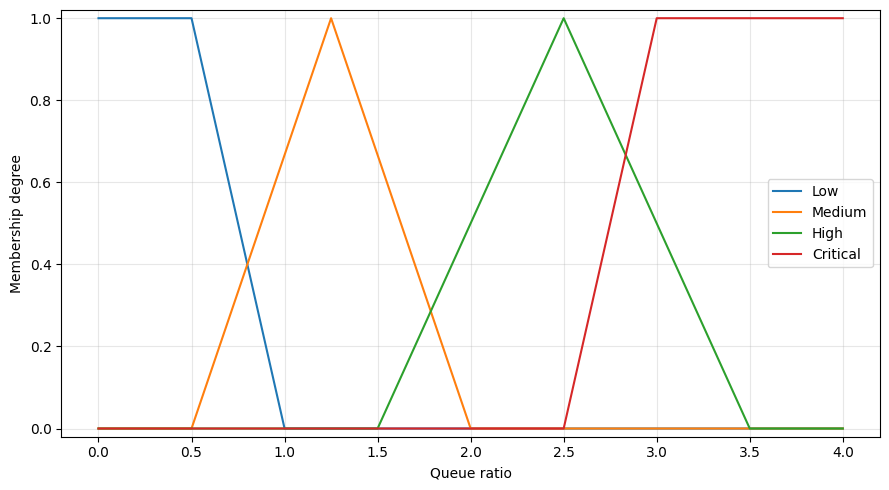

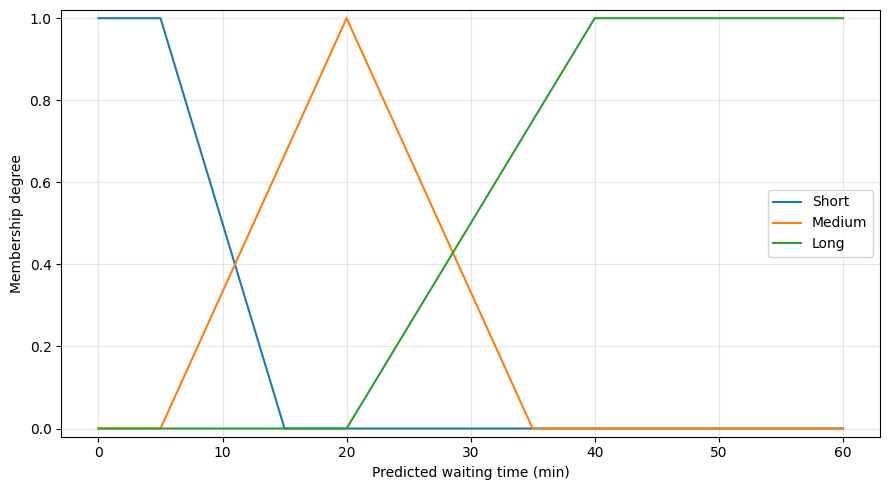

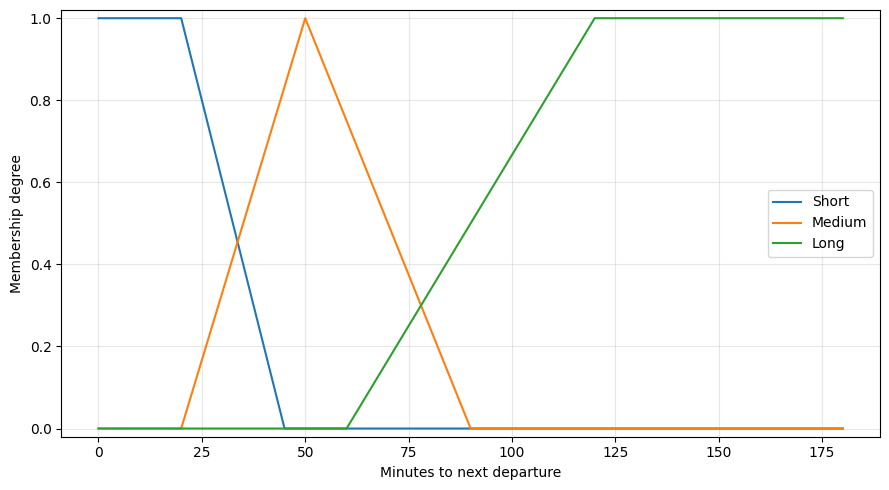

,check,failed_rows
0,below_zero,0
1,above_one,0
2,missing_membership,0


In [4]:
S5=STAGE/"stage_05"
df.to_csv(S5/"05_fuzzy_memberships.csv",index=False)

plots=[
 ("queue_ratio",np.linspace(0,4,401),[
  ("Low",lambda x:left(x,.5,1)),("Medium",lambda x:tri(x,.5,1.25,2)),
  ("High",lambda x:tri(x,1.5,2.5,3.5)),("Critical",lambda x:right(x,2.5,3))
 ],"Queue ratio"),
 ("predicted_wait",np.linspace(0,60,301),[
  ("Short",lambda x:left(x,5,15)),("Medium",lambda x:tri(x,5,20,35)),
  ("Long",lambda x:right(x,20,40))
 ],"Predicted waiting time (min)"),
 ("service_gap",np.linspace(0,180,361),[
  ("Short",lambda x:left(x,20,45)),("Medium",lambda x:tri(x,20,50,90)),
  ("Long",lambda x:right(x,60,120))
 ],"Minutes to next departure"),
]
for name,x,curves,xlabel in plots:
    plt.figure(figsize=(9,5))
    for label,fn in curves: plt.plot(x,fn(x),label=label)
    plt.xlabel(xlabel); plt.ylabel("Membership degree")
    plt.ylim(-.02,1.02); plt.grid(True,alpha=.3); plt.legend(); plt.tight_layout()
    plt.savefig(S5/f"05_membership_{name}.png",dpi=180)
    plt.show()

audit=pd.DataFrame({
 "check":["below_zero","above_one","missing_membership"],
 "failed_rows":[
  int((df.filter(regex="^mu_")<0).sum().sum()),
  int((df.filter(regex="^mu_")>1).sum().sum()),
  int(df.filter(regex="^mu_").isna().sum().sum())
 ]
})
audit.to_csv(S5/"05_fuzzification_audit.csv",index=False)
display(audit)